In [75]:
# --- import required libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [76]:
# --- import data ---
df = pd.read_csv('/kaggle/input/datasets/kanchitank/indian-names-male-and-female/Names_dataset.csv')
df.head(5)

,name,gender
0,alfiya,f
1,ardwin,m
2,henryka,f
3,preeti,f
4,jamaro,m


In [77]:
# --- about ---
print("Shape",df.shape)
print("=============================\n")
print(df.info())
print("=============================\n")
print(df.describe())
print("=============================\n")
print(df.isna().sum())
print("=============================\n")
print('Duplicated Value',df.duplicated().sum())

Shape (125231, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125231 entries, 0 to 125230
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   name    125175 non-null  object
 1   gender  125231 non-null  object
dtypes: object(2)
memory usage: 1.9+ MB
None

          name  gender
count   125175  125231
unique  108568       2
top      pooja       f
freq       357   75971

name      56
gender     0
dtype: int64

Duplicated Value 16317


- Just 56 null values in the name column, we can just delete them.
- 16317 duplicated value, we also have to delete those. 

In [78]:
df['gender'].value_counts()

gender
f    75971
m    49260
Name: count, dtype: int64

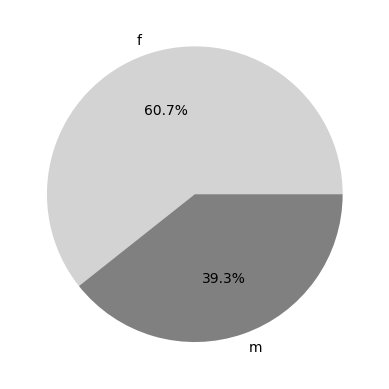

In [79]:
# --- Distribution of genders ---
gender_counts = df['gender'].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%', 
    colors = ['lightgray', 'gray']
)

plt.show()

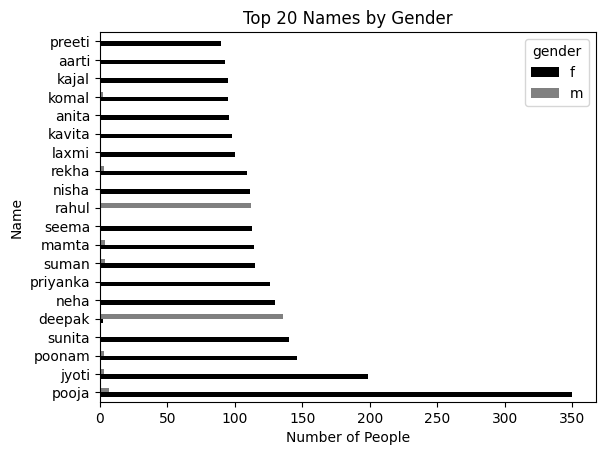

In [80]:
# --- value count of names ---
top_names = (
    df.groupby(['name', 'gender'])
      .size()
      .unstack(fill_value=0)
)

top_names['total'] = top_names.sum(axis=1)
top_names = top_names.sort_values('total', ascending=False).head(20)
top_names = top_names.drop(columns='total')

top_names.plot(
    kind='barh',
    color=['black', 'gray']
)

plt.xlabel('Number of People')
plt.ylabel('Name')
plt.title('Top 20 Names by Gender')
plt.show()

In [81]:
# --- Let's drop duplicates and null
df.drop_duplicates(inplace = True)
df.dropna(inplace = True)

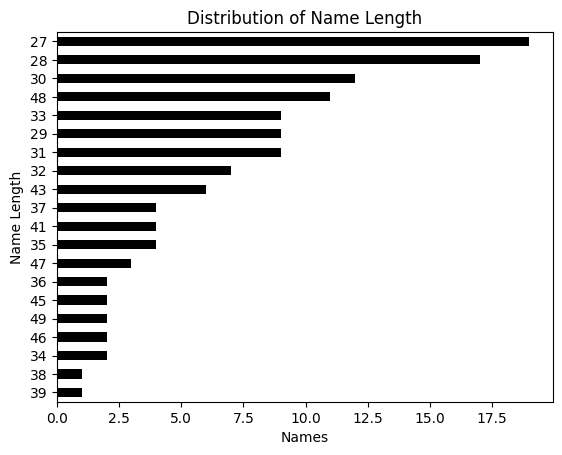

In [82]:
df['length'] = df['name'].str.len()

df['length'].value_counts().sort_values().head(20).plot(
    kind='barh',
    color='black'
)

plt.xlabel('Names')
plt.ylabel('Name Length')
plt.title('Distribution of Name Length')
plt.show()

In [83]:
df[df['length'] > 30].head(30)

,name,gender,length
1688,sadhna bhardwaj do uma shankar bhardwaj,f,39
6301,kamala do gokul singh ro suradiya ps jawaja,f,43
10138,smt bhuri bai wio lt dhanraj lodha,f,34
13811,kumari divya urf kamal do babu lal bairwa,f,41
15640,sushhmita dass and his son ayush dass,f,37
16612,smt sukhdeep kaur wo nishan singh,f,33
18247,kundan kumar choudhary so kedar choudhary r,m,43
20737,vb sumramanya jaya prakash chandra,m,35
21647,shahista do abdul vahid ro khampur ps chhapar zu,f,48
23643,smt somanti w0 ghyanshyam kanjar,f,32


The data is almost looking very clean,But I just found out that some names are contain their adress like RO or Daughter of DO along with the name so we have to clean it first. 

In [84]:
# ---- cleaning the name column ----

# Keep the original column safe
df['clean_name'] = df['name'].copy()

# Convert to lowercase
df['clean_name'] = df['clean_name'].str.lower()

# Remove everything starting from relationship/address keywords
df['clean_name'] = df['clean_name'].str.replace(
    r'\s+(r/o|ro|c/o|co|urf|and his son|and her daughter|ps)\b.*$',
    '',
    regex=True
)

# Remove numbers
df['clean_name'] = df['clean_name'].str.replace(
    r'\d+',
    '',
    regex=True
)

# Remove extra spaces
df['clean_name'] = df['clean_name'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

print(df[df['length'] > 30][['name', 'clean_name']])

                                                    name  \
1688             sadhna bhardwaj do uma shankar bhardwaj   
6301         kamala do gokul singh ro suradiya ps jawaja   
10138                 smt bhuri bai wio lt dhanraj lodha   
13811          kumari divya urf kamal do babu lal bairwa   
15640              sushhmita dass and his son ayush dass   
...                                                  ...   
115647       kailash kour d0 pooran ro ghamudki ps sikri   
115724       rajinder  so hawa singh jat ro shamlo kalan   
116034                 smt krishna devi wo shankar saini   
121348    shri ram so khsyali ram ro umariya ps sindholi   
123390  smt chandrakala devi wo raghuveer lal rov ravigr   

                                              clean_name  
1688             sadhna bhardwaj do uma shankar bhardwaj  
6301                               kamala do gokul singh  
10138                 smt bhuri bai wio lt dhanraj lodha  
13811                                      

I keep the words like "so" or "do" because they may be useful for model training.  Now let's start our Model training. 

In [85]:
# --- encoding and tokenisation ---
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_name'].astype(str)
y = df['gender']

# Label encoding
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(encoder.classes_)

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Vectorisation
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=10000
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

['f' 'm']


In [88]:
# --- Modeling ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_tfidf,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.8216 - loss: 0.3858 - val_accuracy: 0.8637 - val_loss: 0.3145
Epoch 2/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8792 - loss: 0.2816 - val_accuracy: 0.8711 - val_loss: 0.3016
Epoch 3/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8966 - loss: 0.2429 - val_accuracy: 0.8735 - val_loss: 0.2987
Epoch 4/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9112 - loss: 0.2124 - val_accuracy: 0.8769 - val_loss: 0.3048
Epoch 5/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9242 - loss: 0.1847 - val_accuracy: 0.8758 - val_loss: 0.3282
Epoch 6/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9367 - loss: 0.1589 - val_accuracy: 0.8735 - val_loss: 0.3523
Epoch 7/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9459 - loss: 0.1364 - val_accuracy: 0.8751 - val_loss: 0.3764
Epoch 8/10
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9524 - loss: 0

In [90]:
from sklearn.metrics import accuracy_score

y_prob = model.predict(X_test_tfidf)
y_pred = (y_prob >= 0.5).astype(int).flatten()
score = accuracy_score(y_test, y_pred)
print("Accuracy:", score)

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy: 0.8703576183262177


In [105]:
my_name = input('Enter your name: ')

# Convert name into TF-IDF features
my_name_tfidf = vectorizer.transform([my_name])

# Get prediction probability
probability = model.predict(my_name_tfidf)[0][0]

# Convert probability into 0 or 1
prediction = int(probability >= 0.5)

# Convert 0/1 back to gender
gender = encoder.inverse_transform([prediction])[0]

# Calculate confidence
confidence = probability if prediction == 1 else 1 - probability

print(f"Name: {my_name.title()}")
print(f"Predicted Gender: {gender}")
print(f"Confidence: {confidence * 100:.2f}%")

Enter your name:  sukanti


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Name: Sukanti
Predicted Gender: f
Confidence: 96.43%
